# Personality and Social Psychology Analysis
- This dataset contains data on various social and personality traits of individuals which contribute to their overall personality trait (Introvert  or Extrovert)
-  The traits include:
    * time spent alone
    * stage fright
    * frequency/ likelihood to attend social events
    * friends circle size
    * post frequency

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [2]:
df = pd.read_csv("data/personality_dataset.csv")
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   object 
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   object 
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [4]:
# Checking for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:", missing_values)
print("\n")

# Checking for percentage of missing values in each column
missing_percentage = round((df.isnull().sum() / len(df)) * 100,2)
print("Percentage of missing values in each column:", missing_percentage)


Missing values in each column: Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64


Percentage of missing values in each column: Time_spent_Alone             2.17
Stage_fear                   2.52
Social_event_attendance      2.14
Going_outside                2.28
Drained_after_socializing    1.79
Friends_circle_size          2.66
Post_frequency               2.24
Personality                  0.00
dtype: float64


In [5]:
# dropping the missing values
df = df.dropna()
# checking the shape of the dataframe after dropping the missing values
print("Shape of the dataframe after dropping missing values:", df.shape)
# checking the data types of the columns
print("\nData types of the columns:\n", df.dtypes)

Shape of the dataframe after dropping missing values: (2477, 8)

Data types of the columns:
 Time_spent_Alone             float64
Stage_fear                    object
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing     object
Friends_circle_size          float64
Post_frequency               float64
Personality                   object
dtype: object


In [6]:
# Descriptive statistics of the dataset
print("\nDescriptive statistics of the dataset:\n", df.describe())


Descriptive statistics of the dataset:
        Time_spent_Alone  Social_event_attendance  Going_outside  \
count       2477.000000              2477.000000    2477.000000   
mean           4.522406                 3.939039       3.013726   
std            3.491162                 2.900044       2.257239   
min            0.000000                 0.000000       0.000000   
25%            2.000000                 2.000000       1.000000   
50%            4.000000                 3.000000       3.000000   
75%            8.000000                 6.000000       5.000000   
max           11.000000                10.000000       7.000000   

       Friends_circle_size  Post_frequency  
count          2477.000000     2477.000000  
mean              6.239806        3.559548  
std               4.311365        2.927397  
min               0.000000        0.000000  
25%               3.000000        1.000000  
50%               5.000000        3.000000  
75%              10.000000        6.0000

## Exploratory Data Analysis


* This section invloves anwering some questions using the dataset

1. Checking the Class Balance in our dataset

The number of Introverts and Extroverts in our dataset is as follows:


Personality
Extrovert    0.514332
Introvert    0.485668
Name: proportion, dtype: float64

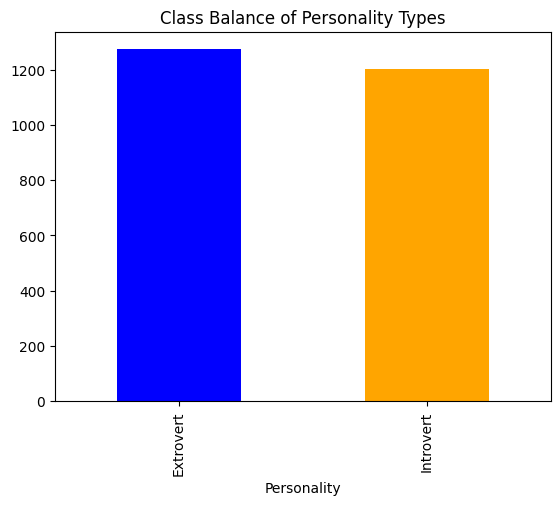

In [7]:
# Checking the class balance between introverts and extoverts
df['Personality'].value_counts().plot(kind='bar', color=['blue', 'orange'])
plt.title('Class Balance of Personality Types')
print("The number of Introverts and Extroverts in our dataset is as follows:")
df["Personality"].value_counts( normalize = True)

* The class balance between Introverts and Extroverts in our dataset seems to be balanced with our dataset having 48.56% as Introverts and 51.43% as Extoverts

2. Do introverts spend more time alone than extroverts?


Average Time_spent_Alone by Personality Type:
 Personality
Extrovert    2.138932
Introvert    7.046550
Name: Time_spent_Alone, dtype: float64


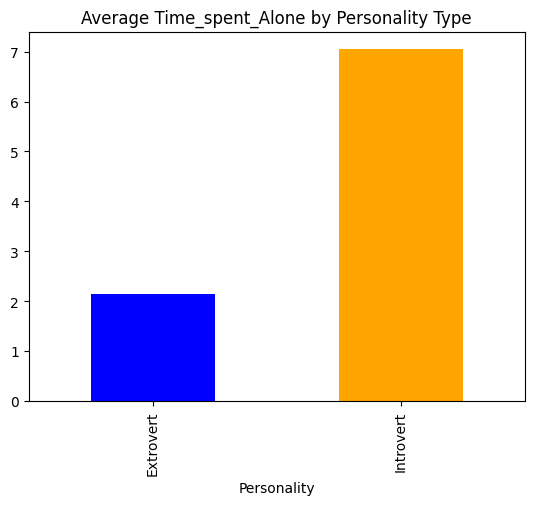

In [8]:
# Do Introverts spend more Time_spent_Alone than extroverts? 
df["Time_spent_Alone"].groupby (df["Personality"]).mean().plot(kind= "bar", color=['blue', 'orange'])
plt.title("Average Time_spent_Alone by Personality Type")
print("\nAverage Time_spent_Alone by Personality Type:\n", df["Time_spent_Alone"].groupby(df["Personality"]).mean())


* According to our dataset, there is a huge disparity between Intoverts and Extroverts with regard to the time they spend alone with Introverts spending an average of around 7 hours alone and extroverts spending around 2 hours alone.

3. Are introverts more likely to experience stage-fright compared to extoverts? 


Stage_fear distribution for Introverts:
 Stage_fear
Yes    0.936825
No     0.063175
Name: proportion, dtype: float64

Stage_fear distribution for Extroverts:
 Stage_fear
No     0.914443
Yes    0.085557
Name: proportion, dtype: float64


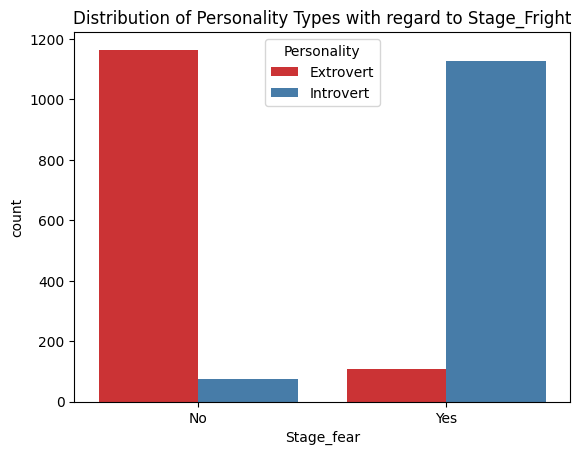

In [9]:
# Distribution of personality types with regard to Stage_Fright
sns.countplot(x="Stage_fear", hue = "Personality", data = df, palette= "Set1")
plt.title("Distribution of Personality Types with regard to Stage_Fright")
# Are introverts more likely to experience stage-fright compared to extroverts?
introvert_stage_fright = df[df["Personality"] == "Introvert"]["Stage_fear"].value_counts(normalize=True)
extrovert_stage_fright = df[df["Personality"] == "Extrovert"]["Stage_fear"].value_counts(normalize=True)
print("\nStage_fear distribution for Introverts:\n", introvert_stage_fright)
print("\nStage_fear distribution for Extroverts:\n", extrovert_stage_fright)

* According to our dataset:
    * Over 93.6% of Introverts are likely to experience stage-fright.
    * Only 8.5% of Extroverts are likely to experience stage-fright.

4. Indoor VS. Outdoor


Average Likelihood to Spend Time Outdoors by Personality Type:
 Personality
Extrovert    4.620094
Introvert    1.312552
Name: Going_outside, dtype: float64


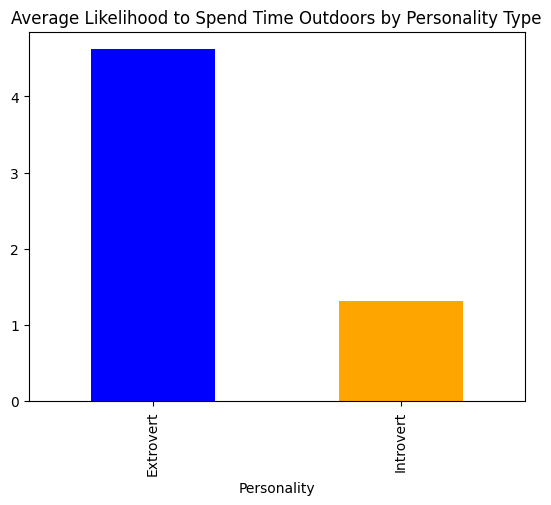

In [10]:
#Who is more likely to spend most of the time outdoors?
indoor_outdoor = df.groupby("Personality")["Going_outside"].mean()
indoor_outdoor.plot(kind="bar", color=['blue', 'orange'])
plt.title("Average Likelihood to Spend Time Outdoors by Personality Type")
print("\nAverage Likelihood to Spend Time Outdoors by Personality Type:\n", indoor_outdoor)



* According to our data, Extroverts are over 3 times more likely to go outside on average as compared to Introverts.

5. Likelihood to attend social events

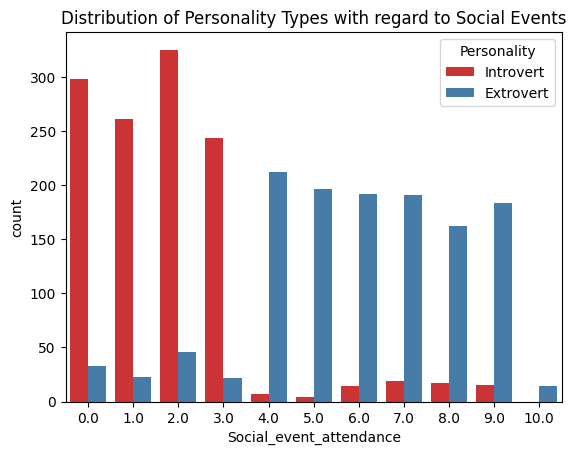


Social_event_attendance distribution for Introverts:
 Social_event_attendance
2.0    0.270158
0.0    0.247714
1.0    0.216958
3.0    0.201995
7.0    0.015794
8.0    0.014131
9.0    0.012469
6.0    0.011638
4.0    0.005819
5.0    0.003325
Name: proportion, dtype: float64

Social_event_attendance distribution for Extroverts:
 Social_event_attendance
4.0     0.166405
5.0     0.153846
6.0     0.150706
7.0     0.149922
9.0     0.143642
8.0     0.127159
2.0     0.036107
0.0     0.025903
1.0     0.018053
3.0     0.017268
10.0    0.010989
Name: proportion, dtype: float64


In [11]:
# Who is more likely to attend social events? 
sns.countplot(x="Social_event_attendance", hue = "Personality", data = df, palette= "Set1")
plt.title("Distribution of Personality Types with regard to Social Events")
plt.show()
# Are introverts more likely to attend social events compared to extroverts?
introvert_social_events = df[df["Personality"] == "Introvert"]["Social_event_attendance"].value_counts(normalize = True)
extrovert_social_events = df[df["Personality"] == "Extrovert"]["Social_event_attendance"].value_counts(normalize = True)
print("\nSocial_event_attendance distribution for Introverts:\n", introvert_social_events)
print("\nSocial_event_attendance distribution for Extroverts:\n", extrovert_social_events)


* According to our dataset, Extroverts are more likely to attend social events as compared to Introverts.

6. Emotional Well-being after social Interaction

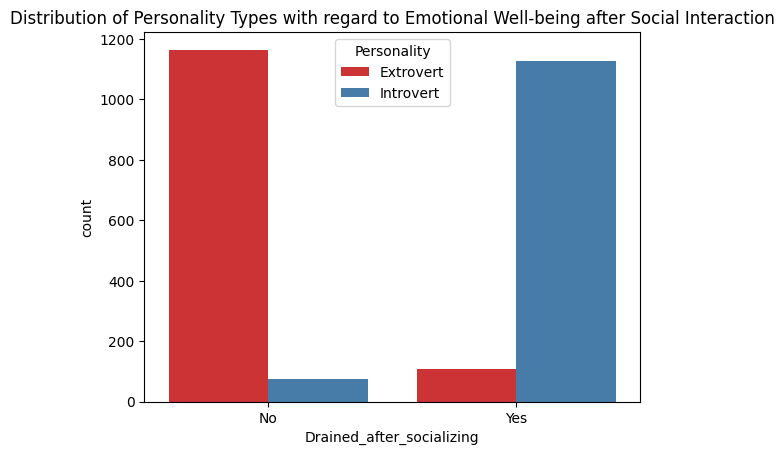


Drained_after_socializing distribution for Introverts:
 Drained_after_socializing
Yes    0.936825
No     0.063175
Name: proportion, dtype: float64

Drained_after_socializing distribution for Extroverts:
 Drained_after_socializing
No     0.914443
Yes    0.085557
Name: proportion, dtype: float64
Introverts are more likely to feel drained after socializing compared to Extroverts.


In [12]:
# Who feels more emotionally drained after social interaction?
sns.countplot(x="Drained_after_socializing", hue = "Personality", data = df, palette= "Set1")
plt.title("Distribution of Personality Types with regard to Emotional Well-being after Social Interaction")
plt.show()
# Are introverts more likely to feel drained after socializing compared to extroverts?
introvert_drained = df[df["Personality"] == "Introvert"]["Drained_after_socializing"].value_counts(normalize = True)
extrovert_drained = df[df["Personality"] == "Extrovert"]["Drained_after_socializing"].value_counts(normalize = True)
print("\nDrained_after_socializing distribution for Introverts:\n", introvert_drained)
print("\nDrained_after_socializing distribution for Extroverts:\n", extrovert_drained)
# Are introverts more likely to feel drained after socializing compared to extroverts?
if introvert_drained['Yes'] > extrovert_drained['Yes']:
    print("Introverts are more likely to feel drained after socializing compared to Extroverts.")
else:
    print("Extroverts are more likely to feel drained after socializing compared to Introverts.")
    

* According to our dataset, Introverts tend to feel more drained after social interaction with over 93.6% of the introverts in our dataset saying yes and only about 8.5 % of extroverts feeling drained after social interaction.

7. Friends Circle


Average Friends Circle Size by Personality Type:
 Personality
Extrovert    9.104396
Introvert    3.206151
Name: Friends_circle_size, dtype: float64
Introverts are more likely to have a smaller friends circle compared to Extroverts.


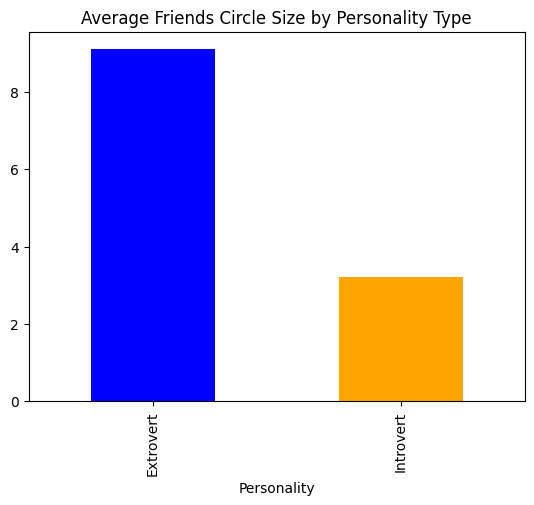

In [13]:
# What is the average number of friends for introverts and extroverts?
df["Friends_circle_size"].groupby(df["Personality"]).mean().plot(kind="bar", color=['blue', 'orange'])
plt.title("Average Friends Circle Size by Personality Type")
print("\nAverage Friends Circle Size by Personality Type:\n", df["Friends_circle_size"].groupby(df["Personality"]).mean())
# Are introverts more likely to have a smaller friends circle compared to extroverts?
introvert_friends = df[df["Personality"] == "Introvert"]["Friends_circle_size"].mean()
extrovert_friends = df[df["Personality"] == "Extrovert"]["Friends_circle_size"].mean()
if introvert_friends < extrovert_friends:
    print("Introverts are more likely to have a smaller friends circle compared to Extroverts.")
else:
    print("Extroverts are more likely to have a smaller friends circle compared to Introverts.")




* According to our dataset, Introverts tend to have around 3 close friends while extroverts tends to have a friends' circle of around 9

8. Post Frequency


Average Post Frequency by Personality Type:
 Personality
Extrovert    5.589482
Introvert    1.409809
Name: Post_frequency, dtype: float64
Introverts are more likely to post less frequently compared to Extroverts.


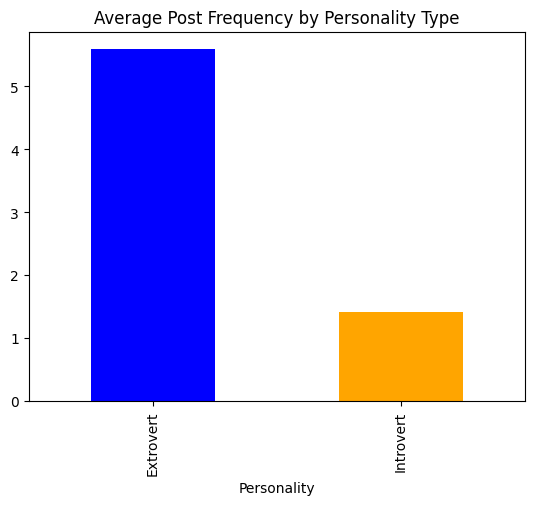

In [14]:
# Who has a higher post frequency on average between Introverts and extroverts?
df["Post_frequency"].groupby(df["Personality"]).mean().plot(kind="bar", color=['blue', 'orange'])
plt.title("Average Post Frequency by Personality Type")
print("\nAverage Post Frequency by Personality Type:\n", df["Post_frequency"].groupby(df["Personality"]).mean())
# Are introverts more likely to post less frequently compared to extroverts?
introvert_post_freq = df[df["Personality"] == "Introvert"]["Post_frequency"].mean()
extrovert_post_freq = df[df["Personality"] == "Extrovert"]["Post_frequency"].mean()
if introvert_post_freq < extrovert_post_freq:
    print("Introverts are more likely to post less frequently compared to Extroverts.")
else:
    print("Extroverts are more likely to post less frequently compared to Introverts.")

* According to our dataset, introverts are far less likely to post frequently (around 1 time(s) out of 10) on social media as compared to extoverts (5 times out of 10)

## Correlation Analysis

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2477 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2477 non-null   float64
 1   Stage_fear                 2477 non-null   object 
 2   Social_event_attendance    2477 non-null   float64
 3   Going_outside              2477 non-null   float64
 4   Drained_after_socializing  2477 non-null   object 
 5   Friends_circle_size        2477 non-null   float64
 6   Post_frequency             2477 non-null   float64
 7   Personality                2477 non-null   object 
dtypes: float64(5), object(3)
memory usage: 174.2+ KB


In [16]:
#selecting only numerical columns for correlation analysis
numerical_columns = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size','Post_frequency']


#Calculate the correlation matrix
correlation_matrix = df[numerical_columns].corr()

#Displaying correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                         Time_spent_Alone  Social_event_attendance  \
Time_spent_Alone                 1.000000                -0.733520   
Social_event_attendance         -0.733520                 1.000000   
Going_outside                   -0.753479                 0.752775   
Friends_circle_size             -0.717649                 0.738690   
Post_frequency                  -0.734291                 0.748494   

                         Going_outside  Friends_circle_size  Post_frequency  
Time_spent_Alone             -0.753479            -0.717649       -0.734291  
Social_event_attendance       0.752775             0.738690        0.748494  
Going_outside                 1.000000             0.738999        0.772445  
Friends_circle_size           0.738999             1.000000        0.713145  
Post_frequency                0.772445             0.713145        1.000000  


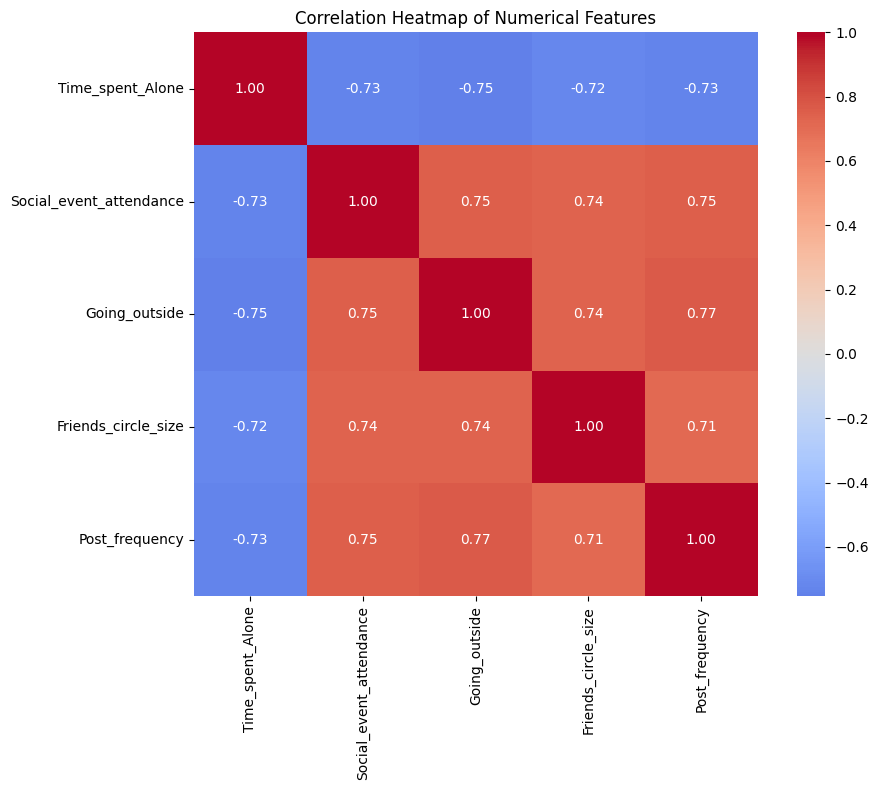

In [17]:
# Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot = True, # correlation values
    cmap = 'coolwarm', # Color scheme
    center= 0, # centering the color map
    fmt = '.2f', #format correlation values to 2 decimal places
    square = True # make the plot square
)
# title
plt.title("Correlation Heatmap of Numerical Features")
# adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()

* After plotting the correlation matrix for the numerical features, these were the findings:
    1. Strongest Positive Correlations (0.7 to 1.0):
        * Going_outside and Post_frequency (0.77)
            - This suggests that spend more time outdoors tend to post more on social media.
            - This makes sense as more outdoor activities might lead to more content to share.
        * Social_event_attendance and Post_frequency (0.75)
            - People who attend more social events tend to post more frequently.
            - This could indicate that social events provide content for social media posts.
        * Going_outside and Friends_circle_size (0.74)
            - People with larger friends circles tend to go outside more.
            - This suggests that social activities often involve outdoor gatherings.
        * Social_event_attendance and Friends_circle_size (0.74)
            - Peole with larger friends circles attend more social events.
            - This is a logical relationship as more friends typically means more social interactions.

    2. Strongest Negative Correlations
        * Time_spent_Alone and Going_outside (-0.75): People who spend more time alone tend to go outside less. This makes sense as going outside often involves social interaction.
        * Time_spent_Alone and Social_event_attendance (-0.73): People who spend more time alone attend fewer social events. This aligns with the introvert/extrovert personality spectrum.
        * Time_spent_Alone and Post_frequency (-0.73): People who spend more time alone post less frequently on social media. This suggests that social media activity is related to social engagement.

### Key Insights
* The correlation matrix reveals a clear pattern of social behavior
* Features can be grouped into two main categories:
    1. Social engagement indicators (Going_outside, Social_event_attendance, Friends_circle_size, Post_frequency)
    2. Solitary behavior indicator (Time_spent_Alone)
* All social engagement indicators are positively correlated with each other.
* Time_spent_Alone is negatively correlated with all social engagement indicators.

### Implications for Personality Analysis
* The strong correlations support the validity of these features for personality classification.
* The negative correlations with Time_spent_Alone align with the introvert/extrovert spectrum.
* The positive correlations between social activities support the concept of social engagement as a personality trait.




## How do these correlations differ between introverts and extroverts?

In [18]:
# splitting the data into introverts and extroverts
introverts_df = df[df['Personality'] == "Introvert"]
extroverts_df = df[df['Personality'] == "Extrovert"]

# Getting the correlation matrices for each group
intro_correlation = introverts_df[numerical_columns].corr()
extro_correlation = extroverts_df[numerical_columns].corr()

# Displaying the correlation matrices for both
print("Correlation Matrix for Introverts:")
print(intro_correlation)
print("\nCorrelation Matrix for Extroverts")
print(extro_correlation)


Correlation Matrix for Introverts:
                         Time_spent_Alone  Social_event_attendance  \
Time_spent_Alone                 1.000000                -0.420563   
Social_event_attendance         -0.420563                 1.000000   
Going_outside                   -0.434569                 0.614146   
Friends_circle_size             -0.447937                 0.632873   
Post_frequency                  -0.480219                 0.634859   

                         Going_outside  Friends_circle_size  Post_frequency  
Time_spent_Alone             -0.434569            -0.447937       -0.480219  
Social_event_attendance       0.614146             0.632873        0.634859  
Going_outside                 1.000000             0.604315        0.678570  
Friends_circle_size           0.604315             1.000000        0.659669  
Post_frequency                0.678570             0.659669        1.000000  

Correlation Matrix for Extroverts
                         Time_spent_Alone

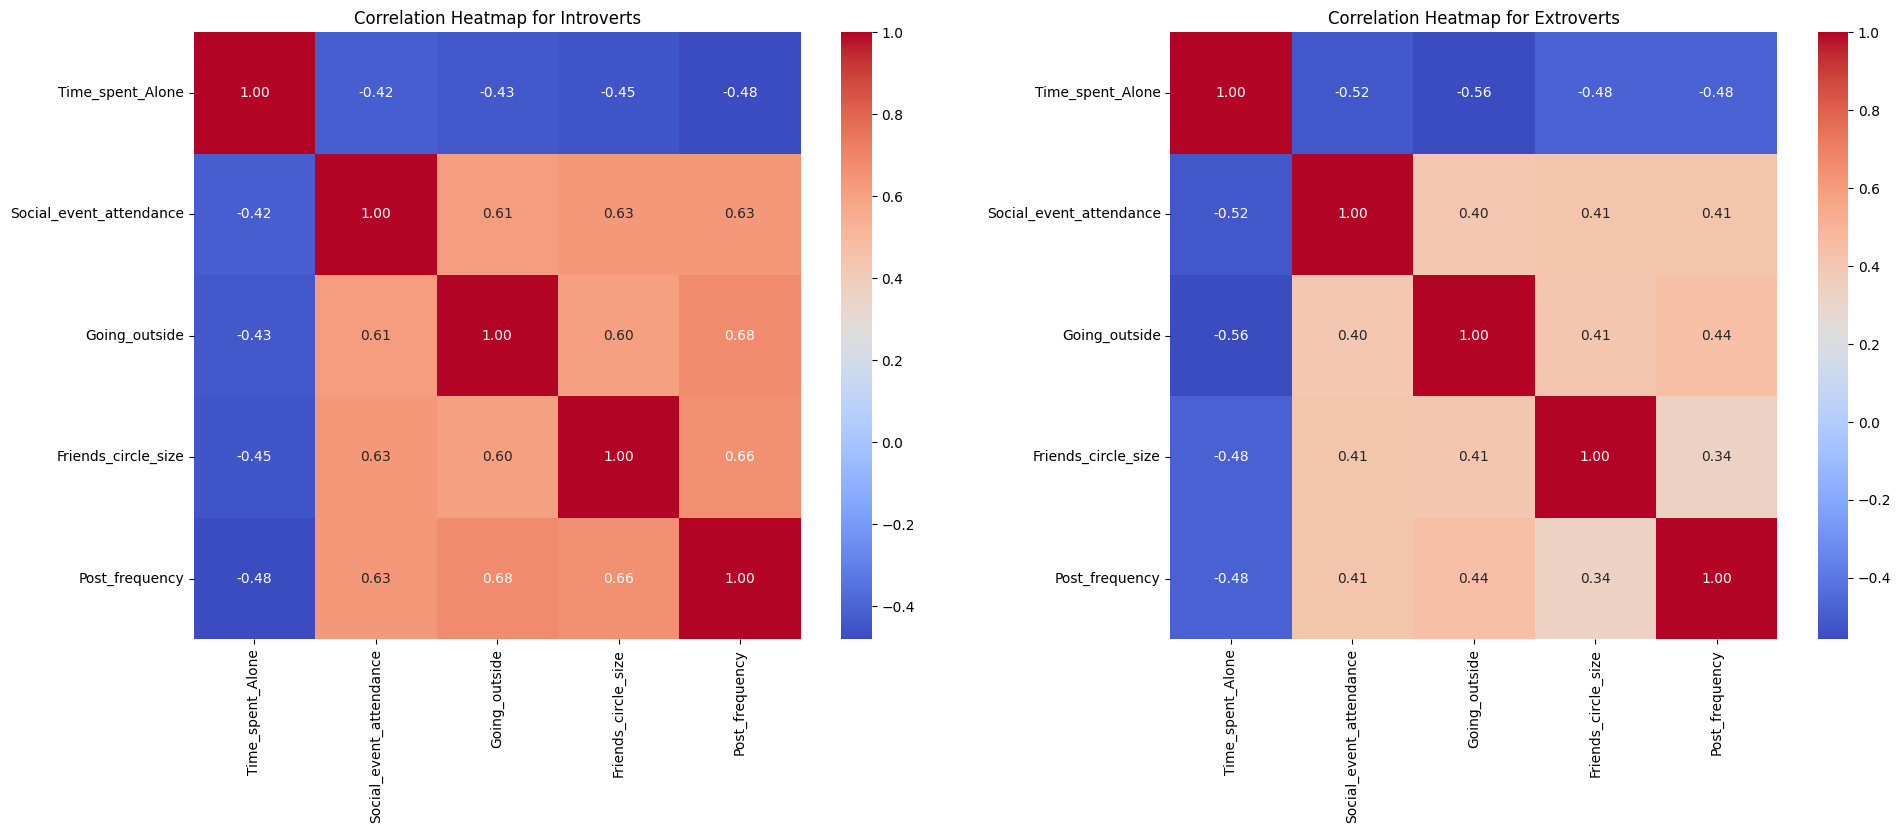

In [19]:
# Heatmap
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (20,8))

# Plot introvert correlation heatmap
sns.heatmap(
    intro_correlation,
    annot = True,
    cmap = "coolwarm",
    fmt = ".2f",
    square = True,
    ax = ax1
)
ax1.set_title("Correlation Heatmap for Introverts")

# Plot extrovert correlation heatmap
sns.heatmap(
    extro_correlation,
    annot = True,
    cmap = "coolwarm",
    fmt = ".2f",
    square = True,
    ax = ax2
)

ax2.set_title("Correlation Heatmap for Extroverts")

plt.tight_layout()
plt.show()


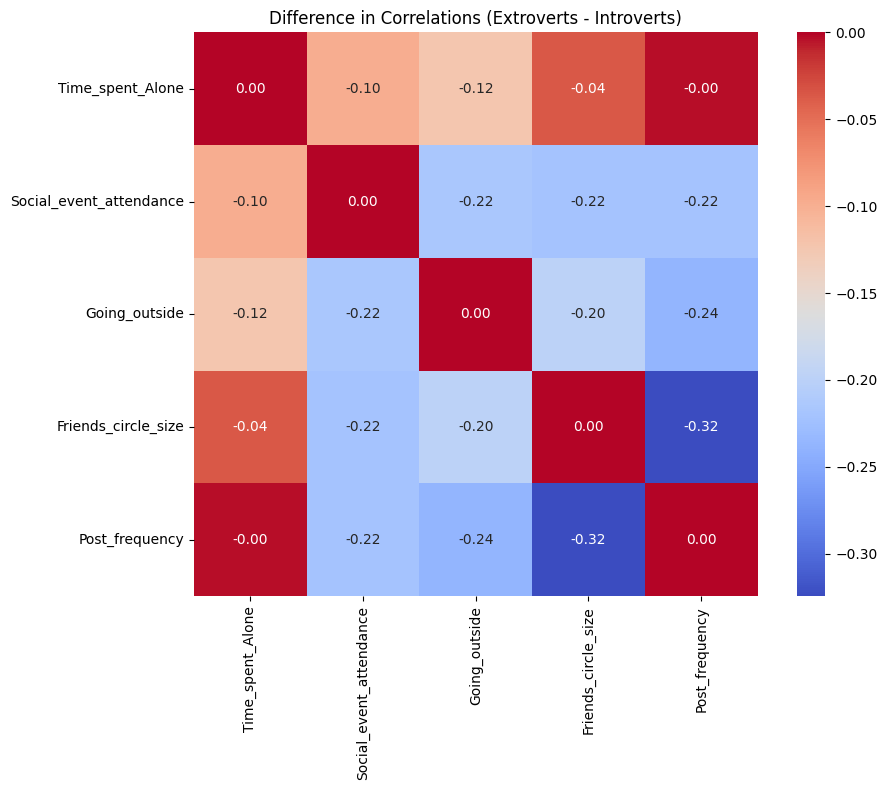

Differences in Correlations (Extroverts - Introverts)
                         Time_spent_Alone  Social_event_attendance  \
Time_spent_Alone                 0.000000                -0.098752   
Social_event_attendance         -0.098752                 0.000000   
Going_outside                   -0.122968                -0.216385   
Friends_circle_size             -0.035852                -0.220663   
Post_frequency                  -0.003550                -0.221708   

                         Going_outside  Friends_circle_size  Post_frequency  
Time_spent_Alone             -0.122968            -0.035852       -0.003550  
Social_event_attendance      -0.216385            -0.220663       -0.221708  
Going_outside                 0.000000            -0.198692       -0.237596  
Friends_circle_size          -0.198692             0.000000       -0.324437  
Post_frequency               -0.237596            -0.324437        0.000000  


In [20]:
# Getting the difference in correlations
correlation_diff = extro_correlation - intro_correlation

# Getting Heatmap of differences
plt.figure(figsize=(10,8))
sns.heatmap(
    correlation_diff,
    annot = True,
    cmap = "coolwarm",
    fmt = ".2f",
    square = True
)

plt.title("Difference in Correlations (Extroverts - Introverts)")
plt.tight_layout()
plt.show()

print("Differences in Correlations (Extroverts - Introverts)")
print(correlation_diff)

In [21]:
# Analyzing specific feature relationships for each group
def compare_correlations(feature1, feature2):
    intro_corr = intro_correlation.loc[feature1, feature2]
    extro_corr = extro_correlation.loc[feature1, feature2]
    diff = extro_corr - intro_corr

    print(f"\nComparing {feature1} and {feature2}")
    print(f"Introvert correlation: {intro_corr:.3f}")
    print(f"Extrovert correlation: {extro_corr:.3f}")
    print(f"Difference: {diff:.3f}")

    if abs(diff) > 0.1:
        print("Notable difference between personality types.")
    else:
        print("Correlation is similar between personality types.")

# Comparing key relationships
print("Analysis of Key Feature Relationships")
compare_correlations('Time_spent_Alone', 'Social_event_attendance')
compare_correlations('Going_outside', 'Post_frequency')
compare_correlations('Friends_circle_size', 'Social_event_attendance')
compare_correlations('Time_spent_Alone', 'Going_outside')

Analysis of Key Feature Relationships

Comparing Time_spent_Alone and Social_event_attendance
Introvert correlation: -0.421
Extrovert correlation: -0.519
Difference: -0.099
Correlation is similar between personality types.

Comparing Going_outside and Post_frequency
Introvert correlation: 0.679
Extrovert correlation: 0.441
Difference: -0.238
Notable difference between personality types.

Comparing Friends_circle_size and Social_event_attendance
Introvert correlation: 0.633
Extrovert correlation: 0.412
Difference: -0.221
Notable difference between personality types.

Comparing Time_spent_Alone and Going_outside
Introvert correlation: -0.435
Extrovert correlation: -0.558
Difference: -0.123
Notable difference between personality types.


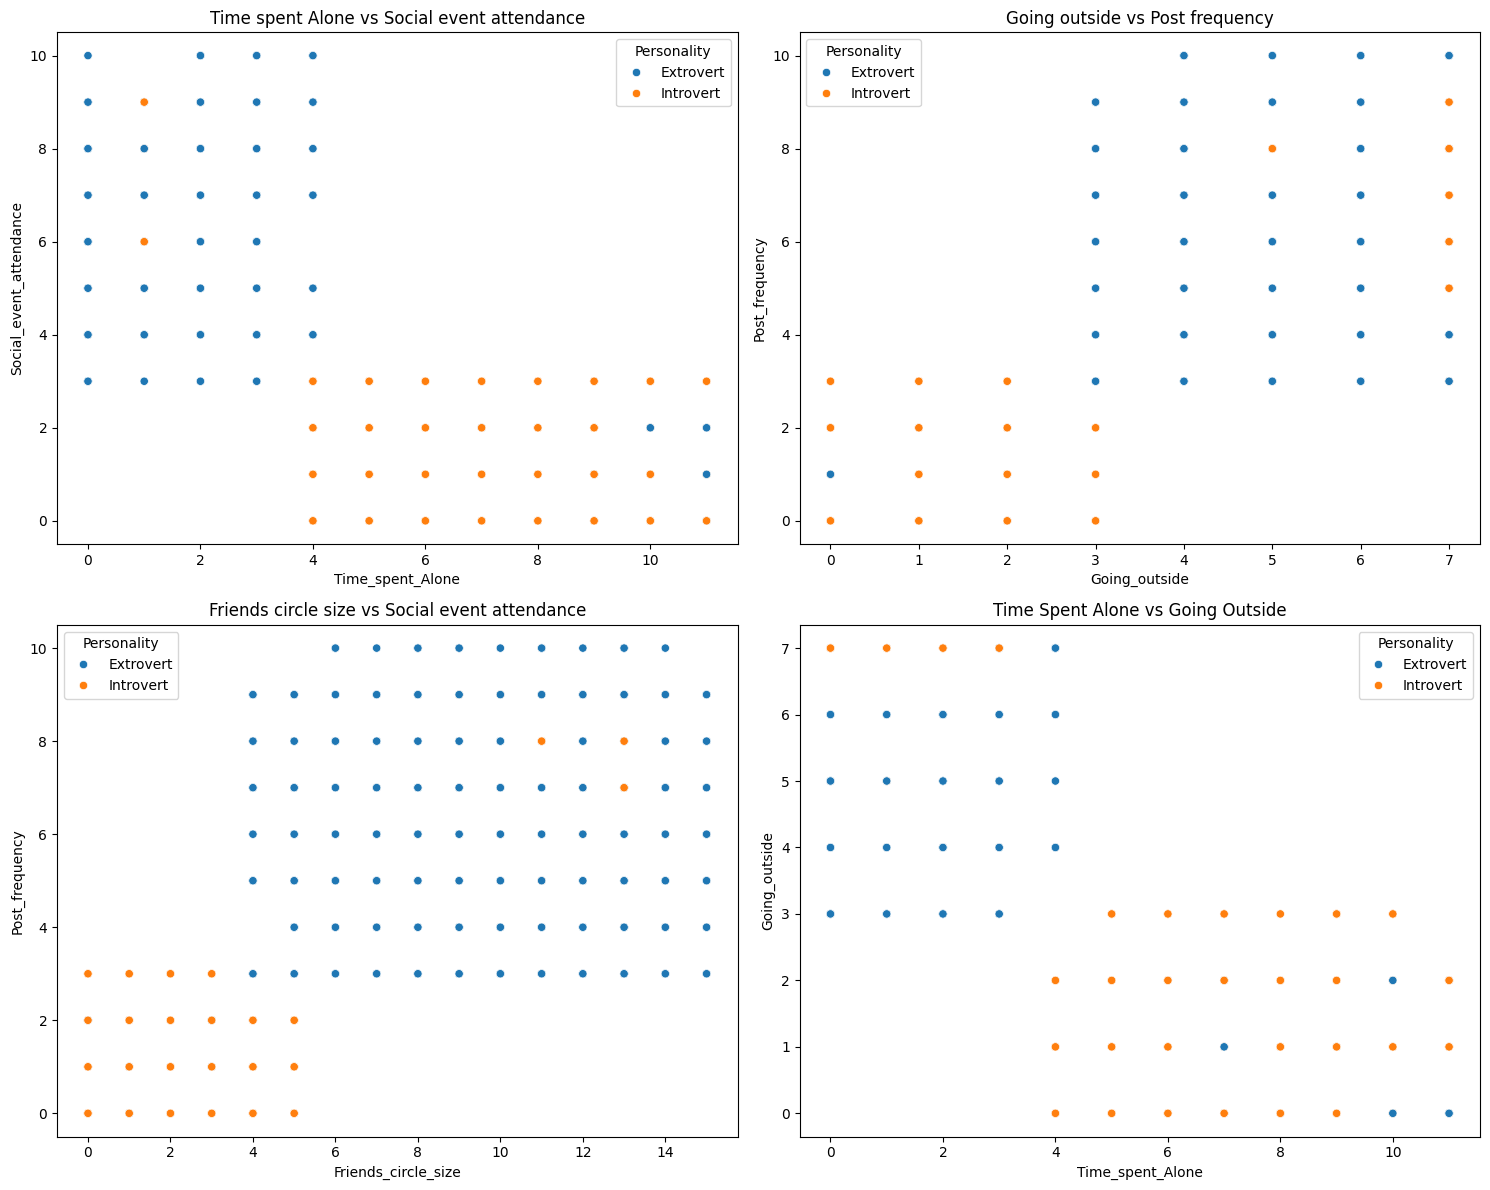

In [22]:
# Visualization of these relationships
#Create scatter plots for key relationships
fig, axes = plt.subplots(2,2, figsize=(15,12))

# Time spent alone vs Social event attendance
sns.scatterplot(
    data = df,
    x = 'Time_spent_Alone',
    y = 'Social_event_attendance',
    hue = 'Personality',
    ax = axes[0,0]
)
axes[0,0].set_title("Time spent Alone vs Social event attendance")

# Going outside vs Post Frequency
sns.scatterplot(
    data = df,
    x = 'Going_outside',
    y = 'Post_frequency',
    hue = 'Personality',
    ax = axes[0,1]
)
axes[0,1].set_title("Going outside vs Post frequency")

# Friends Circle Size vs Social event attendance
sns.scatterplot(
    data = df,
    x = 'Friends_circle_size',
    y = 'Post_frequency',
    hue = 'Personality',
    ax = axes[1,0]
)
axes[1,0].set_title("Friends circle size vs Social event attendance")

# Time Spent Alone  vs Going Outside
sns.scatterplot(
    data = df,
    x = 'Time_spent_Alone',
    y = 'Going_outside',
    hue = 'Personality',
    ax = axes[1,1]
)
axes[1,1].set_title("Time Spent Alone vs Going Outside")

plt.tight_layout()
plt.show()

In [23]:
# Summary
# Largest difference in correlations
print("Summary of Key Differences in Correlations")

# Flatten correlation difference matrix
diff_flat = correlation_diff.unstack()
# Sort by absolute difference
diff_flat = diff_flat[abs(diff_flat) > 0.2].sort_values()
print("\nMost notable differences in correlation between personality types: ")
for idx, value in diff_flat.items():
    if idx[0] != idx[1]: #skip self-correlation
        print(f"{idx[0]} and {idx[1]}: {value:.3f}")

Summary of Key Differences in Correlations

Most notable differences in correlation between personality types: 
Friends_circle_size and Post_frequency: -0.324
Post_frequency and Friends_circle_size: -0.324
Post_frequency and Going_outside: -0.238
Going_outside and Post_frequency: -0.238
Social_event_attendance and Post_frequency: -0.222
Post_frequency and Social_event_attendance: -0.222
Social_event_attendance and Friends_circle_size: -0.221
Friends_circle_size and Social_event_attendance: -0.221
Social_event_attendance and Going_outside: -0.216
Going_outside and Social_event_attendance: -0.216


## Findings
1. Overall Correlation Strength:
    * Introverts show stronger correlations between social behaviors *(0.60-0.68)*
    * Extroverts show weaker correlations between social behaviors *(0.33-0.56)*
    * This suggests that introverts' social behaviors are more tightly coupled together.

2. Key Differences in Specific Relationships:

    - Social Event Attendance and Other Features
        * *Introverts: Stronger correlation (0.61-0.63)*
        * *Extroverts: Weaker correlation (0.39-0.41)*
        * This suggests that for introverts, social event attendance is more closely tied to other social behaviors
    - Going Outside and Post Frequency
        * *Introverts: 0.68 correlation*
        * *Extroverts: 0.44 correlation*
        * This indicates that introvers' social media posting is more strongly related to their outdoor activities.
    - Friends Circle Size and Social Event Attendance
        * *Introverts: 0.63 correlation*
        * *Extroverts: 0.41 correlation*
        * This shows that introverts' social event attendance is more closely tied to their friend circle size.
3. Time Spent Alone Relationships:
    * For both groups, Time_spent_Alone has a negative correlation with other features.
    * The correlations are slightly stronger for extroverts *(-0.48 to -0.56)*
    * For introverts, the correlations are slightly weaker *(-0.42 to -0.48)*
    * This suggest that the time spent alone has a more consistent impact on extroverts' social behaviors. 

4. Notable Differences:
    * The largest difference is in the relationship between Going_outside and Social_event_attendance:
        * *Introverts: 0.61 correlation*
        * *Extroverts: 0.40 correlation*
        * *Difference: -0.22*
    * This suggests that introverts' outdoor activities are more closely tied to social events.

5. Implications:
    * Introverts show more consistent patterns in their social behaviors.
    * Extroverts show more independent social behaviors.
    * The relationships between social activities and more pronounced for introverts.
    * Time spent alone has a more uniform effect on extroverts' social behaviors.

6. Behavioral Patterns:
    * Introverts tend to have more coordinated social behaviors.
    * Extroverts show more flexibility in how their social behaviors relate to each other.
    * This might reflect different social engagement strategies between the two personality types.

### Examining The Relationship between Categorical Features

In [24]:
from scipy.stats import chi2_contingency 
import numpy as np 

# calculating Cramer's V
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape)-1
    return np.sqrt(chi2/ (n * min_dim))


# Analyze Stage_fear
print("Analysis of Stage Fear")
stage_fear_contingency = pd.crosstab(df['Stage_fear'],df['Personality'])
print('\nContingency Table:')
print(stage_fear_contingency)
print("Cramer's V: ", cramers_v(stage_fear_contingency))

# Analyze Drained_after_socializing
print('\nAnalysis of Drained After Socializing')
drained_contingency = pd.crosstab(df['Drained_after_socializing'], df['Personality'])
print('\nContingency Table:')
print(drained_contingency)
print("\nCramer's V:", cramers_v(drained_contingency))

#

Analysis of Stage Fear

Contingency Table:
Personality  Extrovert  Introvert
Stage_fear                       
No                1165         76
Yes                109       1127
Cramer's V:  0.8501115011230372

Analysis of Drained After Socializing

Contingency Table:
Personality                Extrovert  Introvert
Drained_after_socializing                      
No                              1165         76
Yes                              109       1127

Cramer's V: 0.8501115011230372


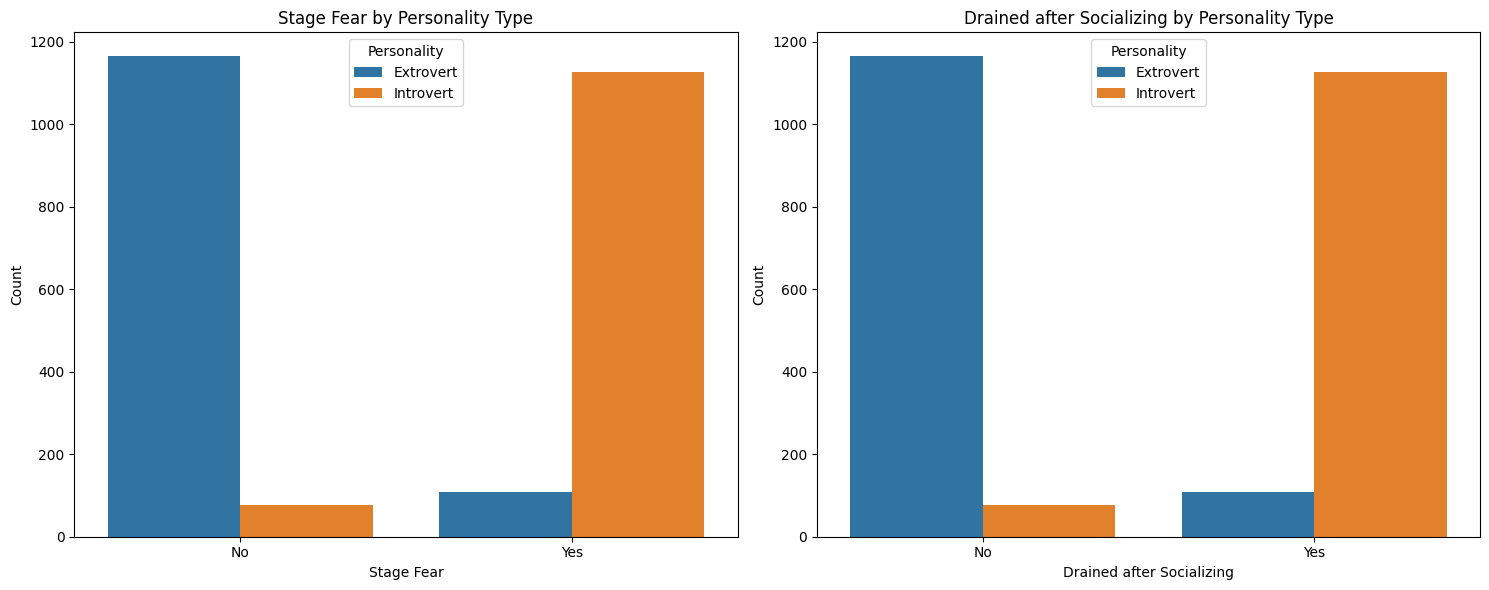

In [25]:
# Visualization of relationships
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,6))

#Plotting Stage_fear
sns.countplot(data = df, x = 'Stage_fear', hue = 'Personality', ax = ax1)
ax1.set_title('Stage Fear by Personality Type')
ax1.set_xlabel('Stage Fear')
ax1.set_ylabel('Count')

#Plot Drained_after_socializing
sns.countplot(data = df, x = 'Drained_after_socializing', hue = 'Personality', ax = ax2)
ax2.set_title('Drained after Socializing by Personality Type')
ax2.set_xlabel('Drained after Socializing')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [29]:
# Conditional Probabilities
# Calculate conditional probabilities for Stage_fear 
print('Conditional Probabilities for Stage_fear:')
stage_fear_probs = pd.crosstab(df['Stage_fear'], df['Personality'])
print('\nProbability of Stage_fear given Personality:')
print(stage_fear_probs)

# Calculate conditional probabilities for Drained_after_socializing 
print('\nConditional Probabilities for Drained_after_socializing:')
drained_probs = pd.crosstab(df['Drained_after_socializing'], df['Personality'])
print('\nProbability of Drained_after_socializing given Personality:')
# Calculating the conditional probabilities for both variables
print("\nConditional Probabilities:")
print("\nStage Fear given Personality:")
print(stage_fear_probs.div(stage_fear_probs.sum(axis=0), axis=1))
print("\nDrained after Socializing given Personality:")
print(drained_probs.div(drained_probs.sum(axis=0), axis=1))


Conditional Probabilities for Stage_fear:

Probability of Stage_fear given Personality:
Personality  Extrovert  Introvert
Stage_fear                       
No                1165         76
Yes                109       1127

Conditional Probabilities for Drained_after_socializing:

Probability of Drained_after_socializing given Personality:

Conditional Probabilities:

Stage Fear given Personality:
Personality  Extrovert  Introvert
Stage_fear                       
No            0.914443   0.063175
Yes           0.085557   0.936825

Drained after Socializing given Personality:
Personality                Extrovert  Introvert
Drained_after_socializing                      
No                          0.914443   0.063175
Yes                         0.085557   0.936825


Relationship between Stage_fear and Dreained_after_socializing

Contingency Table:

Cramer's V:  0.9991925683692815


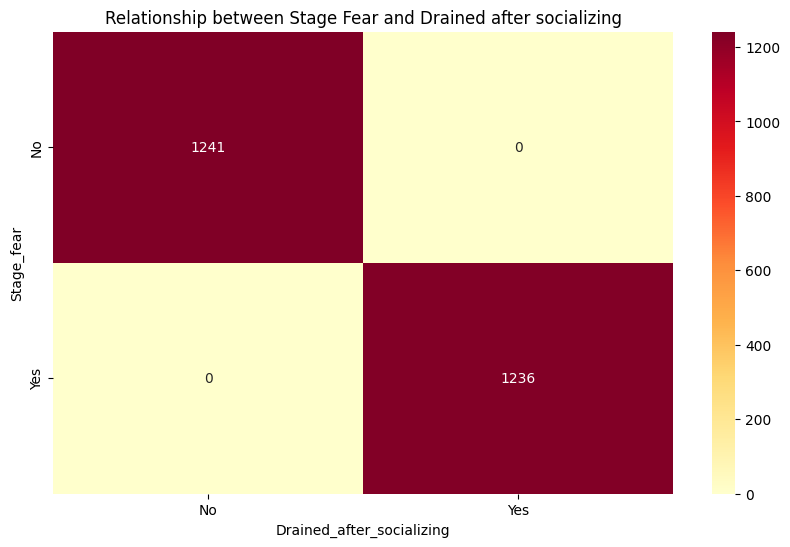

In [33]:

print("Relationship between Stage_fear and Dreained_after_socializing")
combined_contingency = pd.crosstab(df['Stage_fear'], df['Drained_after_socializing'])
print("\nContingency Table:")
print("\nCramer's V: ", cramers_v(combined_contingency))

#Visualizing the relationship
plt.figure(figsize=(10,6))
sns.heatmap(
    combined_contingency,
    annot = True,
    fmt = 'd',
    cmap = 'YlOrRd'
)
plt.title("Relationship between Stage Fear and Drained after socializing")
plt.show()

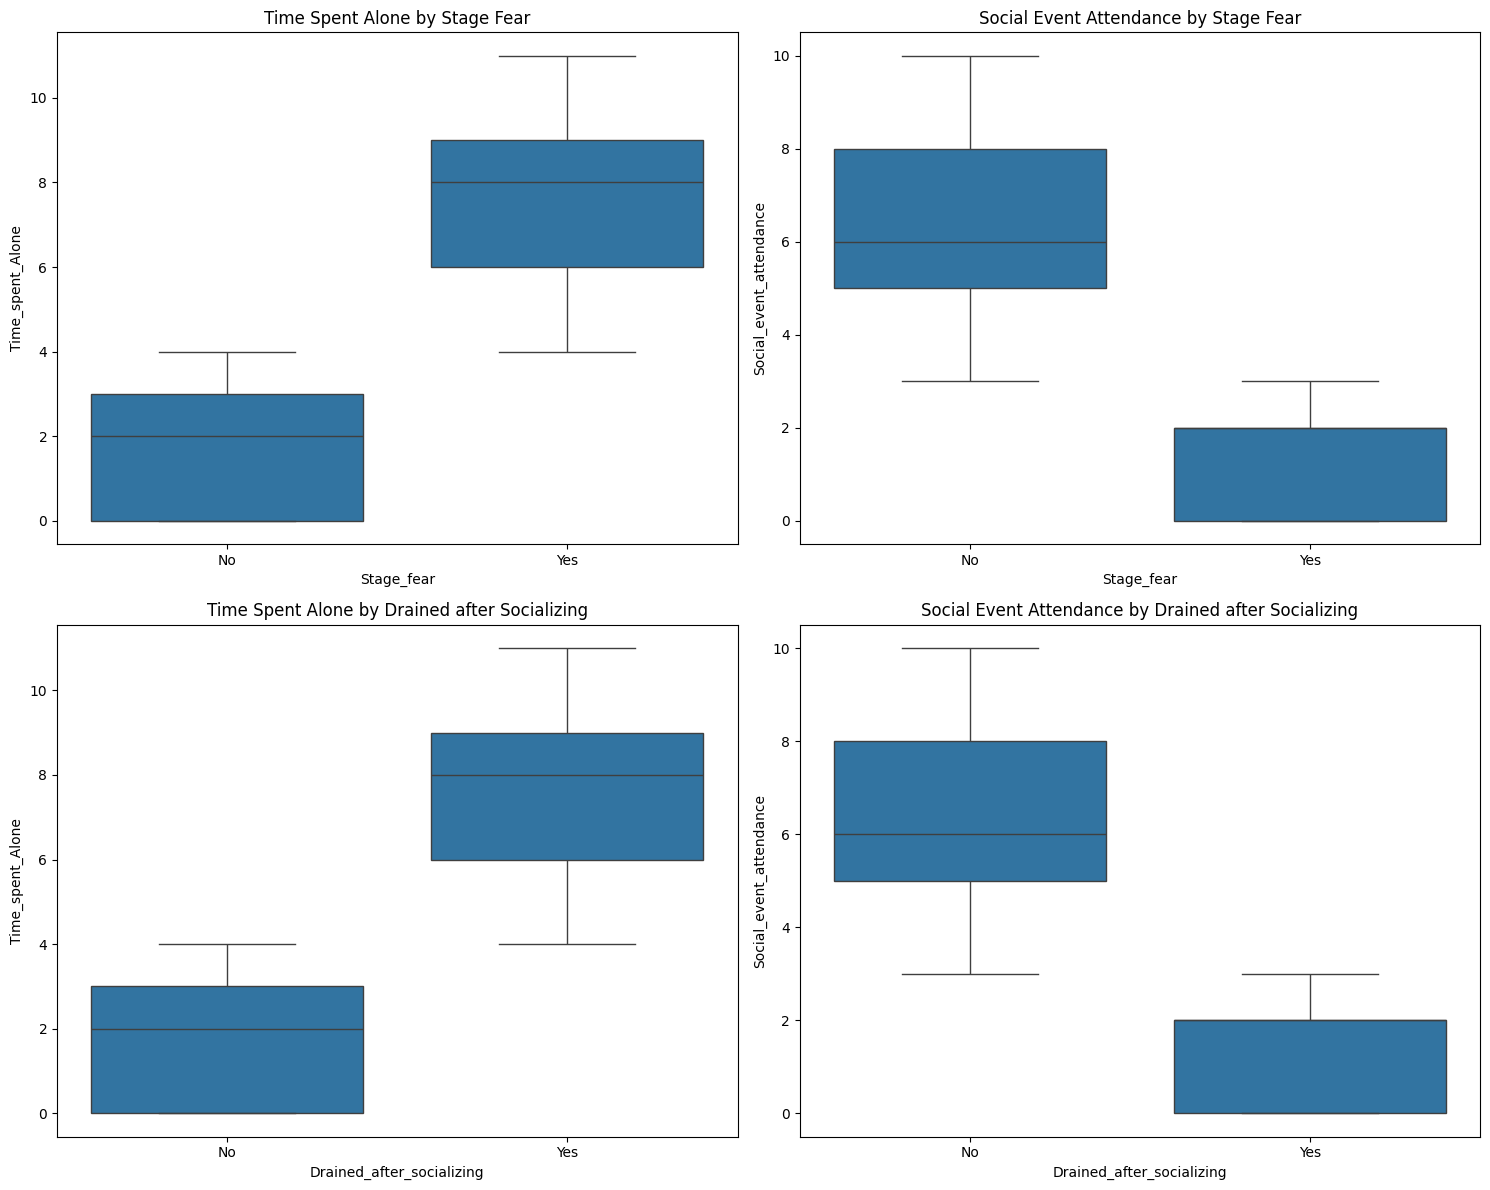

In [34]:
# Relationship between categorical features and numerical features
# Create box plots for numerical features by categorical features
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Time spent alone by Stage_fear
sns.boxplot(data=df, x='Stage_fear', y='Time_spent_Alone', ax=axes[0,0])
axes[0,0].set_title('Time Spent Alone by Stage Fear')

# Social event attendance by Stage_fear
sns.boxplot(data=df, x='Stage_fear', y='Social_event_attendance', ax=axes[0,1])
axes[0,1].set_title('Social Event Attendance by Stage Fear')

# Time spent alone by Drained_after_socializing
sns.boxplot(data=df, x='Drained_after_socializing', y='Time_spent_Alone', ax=axes[1,0])
axes[1,0].set_title('Time Spent Alone by Drained after Socializing')

# Social event attendance by Drained_after_socializing
sns.boxplot(data=df, x='Drained_after_socializing', y='Social_event_attendance', ax=axes[1,1])
axes[1,1].set_title('Social Event Attendance by Drained after Socializing')

plt.tight_layout()
plt.show()

1. Stage Fear Analysis:
    * Cramer's V = 0.85 (shows a very strong association with personality)
    * Contingency Table shows:
        - 91.4% of Extroverts have **No** stage fear
        - 93.7% of Introverts have **Yes** stage fear
    * This indicates a very strong relationship between stage fear and personality type.
    * The relationship is almost perfect, suggesting stage fear is a very reliable indicator of personality type.

2. Drained After Socializing Analysis:
    * Cramer's V= 0.85 (very strong association with personality)
    * Contingency Table shows:
        - 91.4% of Extroverts do **NOT** feel drained after socializing.
        - 93.7% of Introverts **DO** feel drained after socializing
    * This shows an equally strong relationship between feeling drained and personality type.
    * The pattern is very similar to stage fear, suggesting these are closely related behaviors.

3. Relationship between Stage Fear and Drained After Socializing:
    * Cramer's V = 0.999 (almost perfect association)
    * This extremely high value suggests these two features are almost perfectly correlated.
    * This means that people who experience stage fear are almost always the same who feel drained after socializing.
    * This strong relationship suggests these might be measuring the same underlying trait.

Key Insights

    - Both categorical features are excellent predictors of personality type.
    - The features are highly consistent with each other.
    - The patterns are very clear and strong.
    - There's almost no overlap between personality types in these behaviors.

Implications

    - These categorical features are very reliable indicators of personality type.
    - The strong relationship between the features suggests they might be measuring the same underlying anxiety trait.
    - The clear separation between personality types makes these features very valuable for classification.

6. Behavioral Patterns:
    * Extroverts consitently show:
        - No stage fear (91.4%)
        - No feeling drained after socializing (91.4%).
    * Introverts consitently show:
        - Stage fear (93.7%)
        - Feeling drained after socializing (93.7%)
    * This suggests these behaviors are fundamental to the personality types.


